In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [2]:
df= r"D:\Capstone Project\Farmer---Guide---AI\Data\PlantVillage"

print(df)

D:\Capstone Project\Farmer---Guide---AI\Data\PlantVillage


In [3]:
classes=os.listdir(df)
print("Total Classes :",len(classes))
print()
for i in classes:
    print(i)

Total Classes : 15

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_healthy
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_mosaic_virus
Tomato__Tomato_YellowLeaf__Curl_Virus


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.20,
    height_shift_range=0.20,
    shear_range=0.20,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=0.20
)
train_data = train_datagen.flow_from_directory(
    df,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)
valid_data = valid_datagen.flow_from_directory(
    df,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [5]:
print(train_data.class_indices)
print(train_data.num_classes)

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}
15


In [6]:
print(train_data.class_indices)
print("Number of Classes :", len(train_data.class_indices))

{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}
Number of Classes : 15


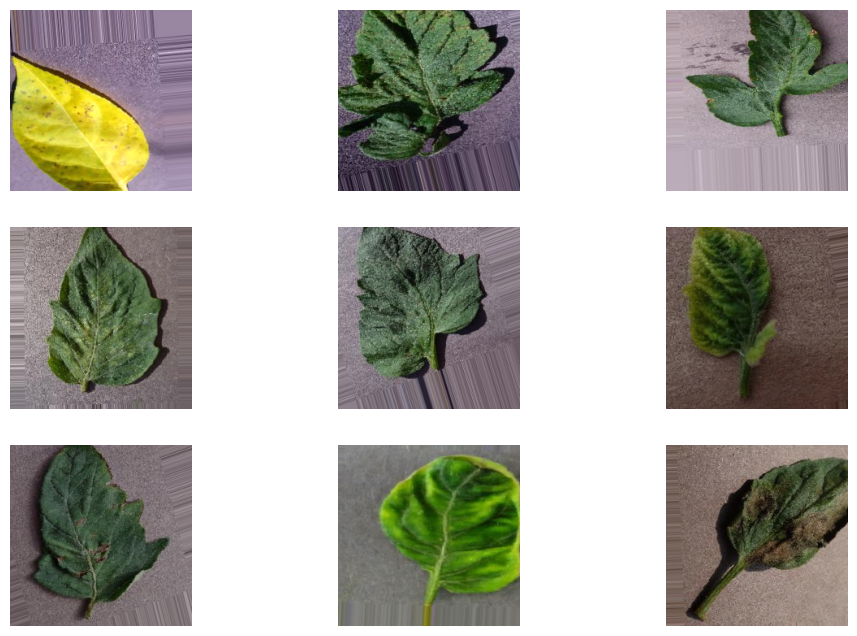

In [7]:
images, labels = next(train_data)
plt.figure(figsize=(12,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [8]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(
    train_data.num_classes,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model Compiled Successfully")

Model Compiled Successfully


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        mode="max",
        restore_best_weights=True
    ),
    ModelCheckpoint(
        r"D:\Capstone Project\Farmer---Guide---AI\Model\disease_model_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )
]
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.5296 - loss: 1.5190 - val_accuracy: 0.7377 - val_loss: 0.8829
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 772s 1s/step - accuracy: 0.7212 - loss: 0.8703 - val_accuracy: 0.8108 - val_loss: 0.6299
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.7753 - loss: 0.7038 - val_accuracy: 0.8331 - val_loss: 0.5325
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.8051 - loss: 0.6156 - val_accuracy: 0.8493 - val_loss: 0.4906
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 713s 1s/step - accuracy: 0.8210 - loss: 0.5602 - val_accuracy: 0.8547 - val_loss: 0.4566
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 514s 995ms/step - accuracy: 0.8371 - loss: 0.5120 - val_accuracy: 0.8610 - val_loss: 0.4264
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 893s 2s/step - accuracy: 0.8394 - loss: 0.4896 - val_accuracy: 0.8700 - val_loss: 0.4017
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.8508 - loss: 0.4577 - val_a

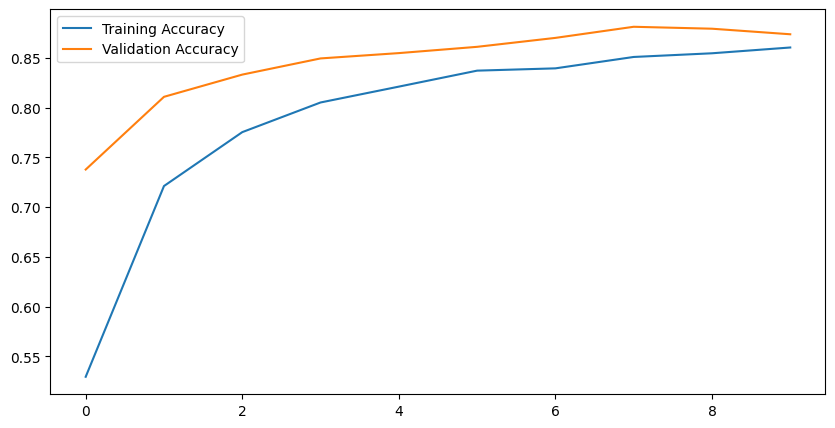

In [12]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.show()

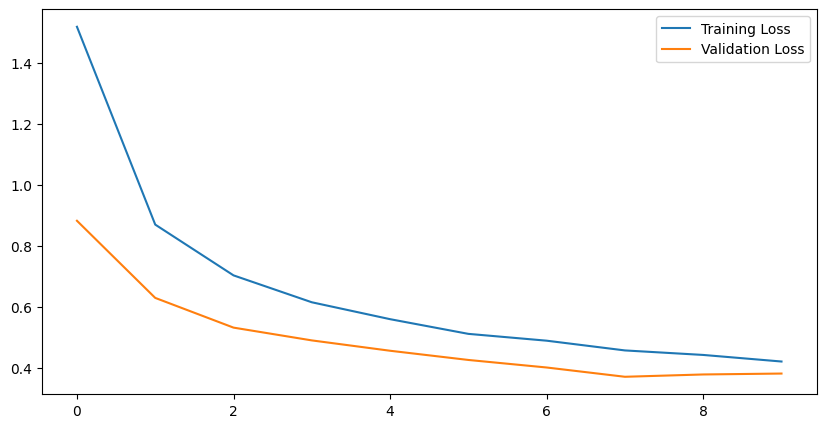

In [13]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.show()

In [14]:
loss, accuracy = model.evaluate(valid_data)
print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy * 100)

129/129 ━━━━━━━━━━━━━━━━━━━━ 60s 465ms/step - accuracy: 0.8811 - loss: 0.3713
Validation Loss : 0.3712557554244995
Validation Accuracy : 88.11256885528564


In [15]:
print("=" * 50)
print(
    "Final Training Accuracy :",
    history.history["accuracy"][-1] * 100
)
print(
    "Final Validation Accuracy :",
    history.history["val_accuracy"][-1] * 100
)
print(
    "Best Training Accuracy :",
    max(history.history["accuracy"]) * 100
)
print(
    "Best Validation Accuracy :",
    max(history.history["val_accuracy"]) * 100
)
best_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1
print("Best Epoch :", best_epoch)
print("=" * 50)

Final Training Accuracy : 86.03172898292542
Final Validation Accuracy : 87.36050724983215
Best Training Accuracy : 86.03172898292542
Best Validation Accuracy : 88.11256885528564
Best Epoch : 8


In [16]:
print("Training Accuracy :", history.history["accuracy"][-1])
print("Validation Accuracy :", history.history["val_accuracy"][-1])

Training Accuracy : 0.8603172898292542
Validation Accuracy : 0.8736050724983215


In [17]:
print("Training Images :", train_data.samples)
print("Validation Images :", valid_data.samples)
print("\nClasses:")
print(train_data.class_indices)

Training Images : 16516
Validation Images : 4122

Classes:
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [18]:
model.save(
    r"D:\Capstone Project\Farmer---Guide---AI\Model\disease_model.keras"
)
print("Disease Model Saved Successfully")

Disease Model Saved Successfully


In [ ]:

# Unfreeze the base model
base_model.trainable = True
# Freeze the first layers and train only the last layers
for layer in base_model.layers[:-40]:
    layer.trainable = False
print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)
# Re-compile with a very small learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Fine-Tuning Model Compiled Successfully")

Trainable layers:
block_12_project_BN
block_12_add
block_13_expand
block_13_expand_BN
block_13_expand_relu
block_13_pad
block_13_depthwise
block_13_depthwise_BN
block_13_depthwise_relu
block_13_project
block_13_project_BN
block_14_expand
block_14_expand_BN
block_14_expand_relu
block_14_depthwise
block_14_depthwise_BN
block_14_depthwise_relu
block_14_project
block_14_project_BN
block_14_add
block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu
Fine-Tuning Model Compiled Successfully


In [ ]:
fine_tune_history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=callbacks
)
print("Fine-Tuning Completed Successfully")

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 597s 1s/step - accuracy: 0.7502 - loss: 0.7714 - val_accuracy: 0.8472 - val_loss: 0.4647
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 784s 2s/step - accuracy: 0.8415 - loss: 0.4834 - val_accuracy: 0.8612 - val_loss: 0.3962
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 797s 2s/step - accuracy: 0.8626 - loss: 0.4086 - val_accuracy: 0.8857 - val_loss: 0.3365
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.8818 - loss: 0.3489 - val_accuracy: 0.9032 - val_loss: 0.2874
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 664s 1s/step - accuracy: 0.8958 - loss: 0.3091 - val_accuracy: 0.9165 - val_loss: 0.2488
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 708s 1s/step - accuracy: 0.9045 - loss: 0.2830 - val_accuracy: 0.9187 - val_loss: 0.2389
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 795s 2s/step - accuracy: 0.9152 - loss: 0.2539 - val_accuracy: 0.9277 - val_loss: 0.2102
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.9224 - loss: 0.2313 - val_accu

In [ ]:
print("=" * 50)
print(
    "Best Fine-Tuning Training Accuracy :",
    max(fine_tune_history.history["accuracy"]) * 100
)
print(
    "Best Fine-Tuning Validation Accuracy :",
    max(fine_tune_history.history["val_accuracy"]) * 100
)
best_epoch = np.argmax(
    fine_tune_history.history["val_accuracy"]
) + 1
print("Best Fine-Tuning Epoch :", best_epoch)
print("=" * 50)

Best Fine-Tuning Training Accuracy : 93.04916262626648
Best Fine-Tuning Validation Accuracy : 93.74090433120728
Best Fine-Tuning Epoch : 9
